## Corrections, 18 September 2026

Three answers in this notebook originally described **a different dataset**. They referred to
`Discount_offered`, `Weight_in_gms`, `Warehouse_block`, `store_type`, `region_code`,
`holiday` and `coupon_category`, none of which exist in this data, and one answer still carried
a "replace with the actual column name you observe" placeholder.

The code and every metric in this notebook were correct. The prose written on top of them was
not reviewed against the output. Questions 1, 3 and 5 have been rewritten from the correlation
table this notebook actually prints.

**The version submitted for assessment is unchanged** and is preserved in the zip archive in
this repository. This notebook is the corrected copy.

One result worth reading the notebook for: Recursive Feature Elimination made the model worse.
All 12 features scored test R² 0.8800; the 8 RFE features scored 0.8191. The 0.8737 from the
scaled run is not a scaling effect, since ordinary least squares is scale-invariant. RFE simply
selected a different set of 8 features on the scaled matrix.


# Order Delivery Time Prediction

## Objectives
The objective of this assignment is to build a regression model that predicts the delivery time for orders placed through Porter. The model will use various features such as the items ordered, the restaurant location, the order protocol, and the availability of delivery partners.

The key goals are:
- Predict the delivery time for an order based on multiple input features
- Improve delivery time predictions to optimiae operational efficiency
- Understand the key factors influencing delivery time to enhance the model's accuracy

## Data Pipeline
The data pipeline for this assignment will involve the following steps:
1. **Data Loading**
2. **Data Preprocessing and Feature Engineering**
3. **Exploratory Data Analysis**
4. **Model Building**
5. **Model Inference**

## Data Understanding
The dataset contains information on orders placed through Porter, with the following columns:

| Field                     | Description                                                                                 |
|---------------------------|---------------------------------------------------------------------------------------------|
| market_id                 | Integer ID representing the market where the restaurant is located.                         |
| created_at                | Timestamp when the order was placed.                                                        |
| actual_delivery_time      | Timestamp when the order was delivered.                                                     |
| store_primary_category    | Category of the restaurant (e.g., fast food, dine-in).                                      |
| order_protocol            | Integer representing how the order was placed (e.g., via Porter, call to restaurant, etc.). |
| total_items               | Total number of items in the order.                                                         |
| subtotal                  | Final price of the order.                                                                   |
| num_distinct_items        | Number of distinct items in the order.                                                      |
| min_item_price            | Price of the cheapest item in the order.                                                    |
| max_item_price            | Price of the most expensive item in the order.                                              |
| total_onshift_dashers     | Number of delivery partners on duty when the order was placed.                              |
| total_busy_dashers        | Number of delivery partners already occupied with other orders.                             |
| total_outstanding_orders  | Number of orders pending fulfillment at the time of the order.                              |
| distance                  | Total distance from the restaurant to the customer.                                         |


## **Importing Necessary Libraries**

In [10]:
# Import essential libraries for data manipulation and analysis
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt  
import seaborn as sns     
import scipy.stats as stats


## **1. Loading the data**
Load 'porter_data_1.csv' as a DataFrame

In [11]:
# Importing the file porter_data_1.csv
df = pd.read_csv('porter_data_1.csv')
print(df.head())



   market_id           created_at actual_delivery_time  \
0        1.0  2015-02-06 22:24:17  2015-02-06 23:11:17   
1        2.0  2015-02-10 21:49:25  2015-02-10 22:33:25   
2        2.0  2015-02-16 00:11:35  2015-02-16 01:06:35   
3        1.0  2015-02-12 03:36:46  2015-02-12 04:35:46   
4        1.0  2015-01-27 02:12:36  2015-01-27 02:58:36   

   store_primary_category  order_protocol  total_items  subtotal  \
0                       4             1.0            4      3441   
1                      46             2.0            1      1900   
2                      36             3.0            4      4771   
3                      38             1.0            1      1525   
4                      38             1.0            2      3620   

   num_distinct_items  min_item_price  max_item_price  total_onshift_dashers  \
0                   4             557            1239                   33.0   
1                   1            1400            1400                    1.0   
2 

## **2. Data Preprocessing and Feature Engineering** <font color = red>[15 marks]</font> <br>

#### **2.1 Fixing the Datatypes**  <font color = red>[5 marks]</font> <br>
The current timestamps are in object format and need conversion to datetime format for easier handling and intended functionality

##### **2.1.1** <font color = red>[2 marks]</font> <br>
Convert date and time fields to appropriate data type

In [12]:
# Convert 'created_at' and 'actual_delivery_time' columns to datetime format
# Convert columns to datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

# Confirm the changes
print(df[['created_at', 'actual_delivery_time']].dtypes)



created_at              datetime64[ns]
actual_delivery_time    datetime64[ns]
dtype: object


##### **2.1.2**  <font color = red>[3 marks]</font> <br>
Convert categorical fields to appropriate data type

In [13]:
# Convert categorical features to category type
categorical_cols = ['market_id', 'store_primary_category', 'order_protocol']

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Confirm the changes
print(df[categorical_cols].dtypes)



market_id                 category
store_primary_category    category
order_protocol            category
dtype: object


#### **2.2 Feature Engineering** <font color = red>[5 marks]</font> <br>
Calculate the time taken to execute the delivery as well as extract the hour and day at which the order was placed

##### **2.2.1** <font color = red>[2 marks]</font> <br>
Calculate the time taken using the features `actual_delivery_time` and `created_at`

In [14]:
# Calculate time taken in minutes
df['time_taken'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60

# Display the first few rows to verify
print(df[['created_at', 'actual_delivery_time', 'time_taken']].head())


           created_at actual_delivery_time  time_taken
0 2015-02-06 22:24:17  2015-02-06 23:11:17        47.0
1 2015-02-10 21:49:25  2015-02-10 22:33:25        44.0
2 2015-02-16 00:11:35  2015-02-16 01:06:35        55.0
3 2015-02-12 03:36:46  2015-02-12 04:35:46        59.0
4 2015-01-27 02:12:36  2015-01-27 02:58:36        46.0


##### **2.2.2** <font color = red>[3 marks]</font> <br>
Extract the hour at which the order was placed and which day of the week it was. Drop the unnecessary columns.

In [16]:
# Extract the hour and day of week from the 'created_at' timestamp
df['order_hour'] = df['created_at'].dt.hour
df['order_day'] = df['created_at'].dt.dayofweek  # Monday = 0, Sunday = 6

# Display a few rows to verify
print(df[['created_at', 'order_hour', 'order_day']].head())


# Create a categorical feature 'isWeekend'
df['isWeekend'] = df['order_day'].apply(lambda x: 1 if x >= 5 else 0)

# Display a few rows to verify
print(df[['order_day', 'isWeekend']].drop_duplicates())



           created_at  order_hour  order_day
0 2015-02-06 22:24:17          22          4
1 2015-02-10 21:49:25          21          1
2 2015-02-16 00:11:35           0          0
3 2015-02-12 03:36:46           3          3
4 2015-01-27 02:12:36           2          1
    order_day  isWeekend
0           4          0
1           1          0
2           0          0
3           3          0
6           6          1
7           5          1
27          2          0


In [17]:
# Drop unnecessary columns
df.drop(['created_at', 'actual_delivery_time'], axis=1, inplace=True)

# Confirm changes
print(df.columns)


Index(['market_id', 'store_primary_category', 'order_protocol', 'total_items',
       'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders', 'distance', 'time_taken', 'order_hour',
       'order_day', 'isWeekend'],
      dtype='object')


#### **2.3 Creating training and validation sets** <font color = red>[5 marks]</font> <br>

##### **2.3.1** <font color = red>[2 marks]</font> <br>
 Define target and input features

In [18]:
# Define target variable (y) and features (X)
X = df.drop('time_taken', axis=1)
y = df['time_taken']

# Confirm shapes
print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (175777, 15)
y shape: (175777,)


##### **2.3.2** <font color = red>[3 marks]</font> <br>
 Split the data into training and test sets

In [19]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # 20% test, 80% train
)

# Confirm the split
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)



Training set size: (140621, 15)
Test set size: (35156, 15)


## **3. Exploratory Data Analysis on Training Data** <font color = red>[20 marks]</font> <br>
1. Analyzing the correlation between variables to identify patterns and relationships
2. Identifying and addressing outliers to ensure the integrity of the analysis
3. Exploring the relationships between variables and examining the distribution of the data for better insights

#### **3.1 Feature Distributions** <font color = red> [7 marks]</font> <br>


In [20]:
# Define numerical and categorical columns for easy EDA and data manipulation
# Define categorical columns
categorical_cols = ['market_id', 'store_primary_category', 'order_protocol', 'isWeekend']

# Define numerical columns (all other columns except categorical and target)
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)




Categorical Columns: ['market_id', 'store_primary_category', 'order_protocol', 'isWeekend']
Numerical Columns: ['total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance', 'order_hour', 'order_day']


##### **3.1.1** <font color = red>[3 marks]</font> <br>
Plot distributions for numerical columns in the training set to understand their spread and any skewness

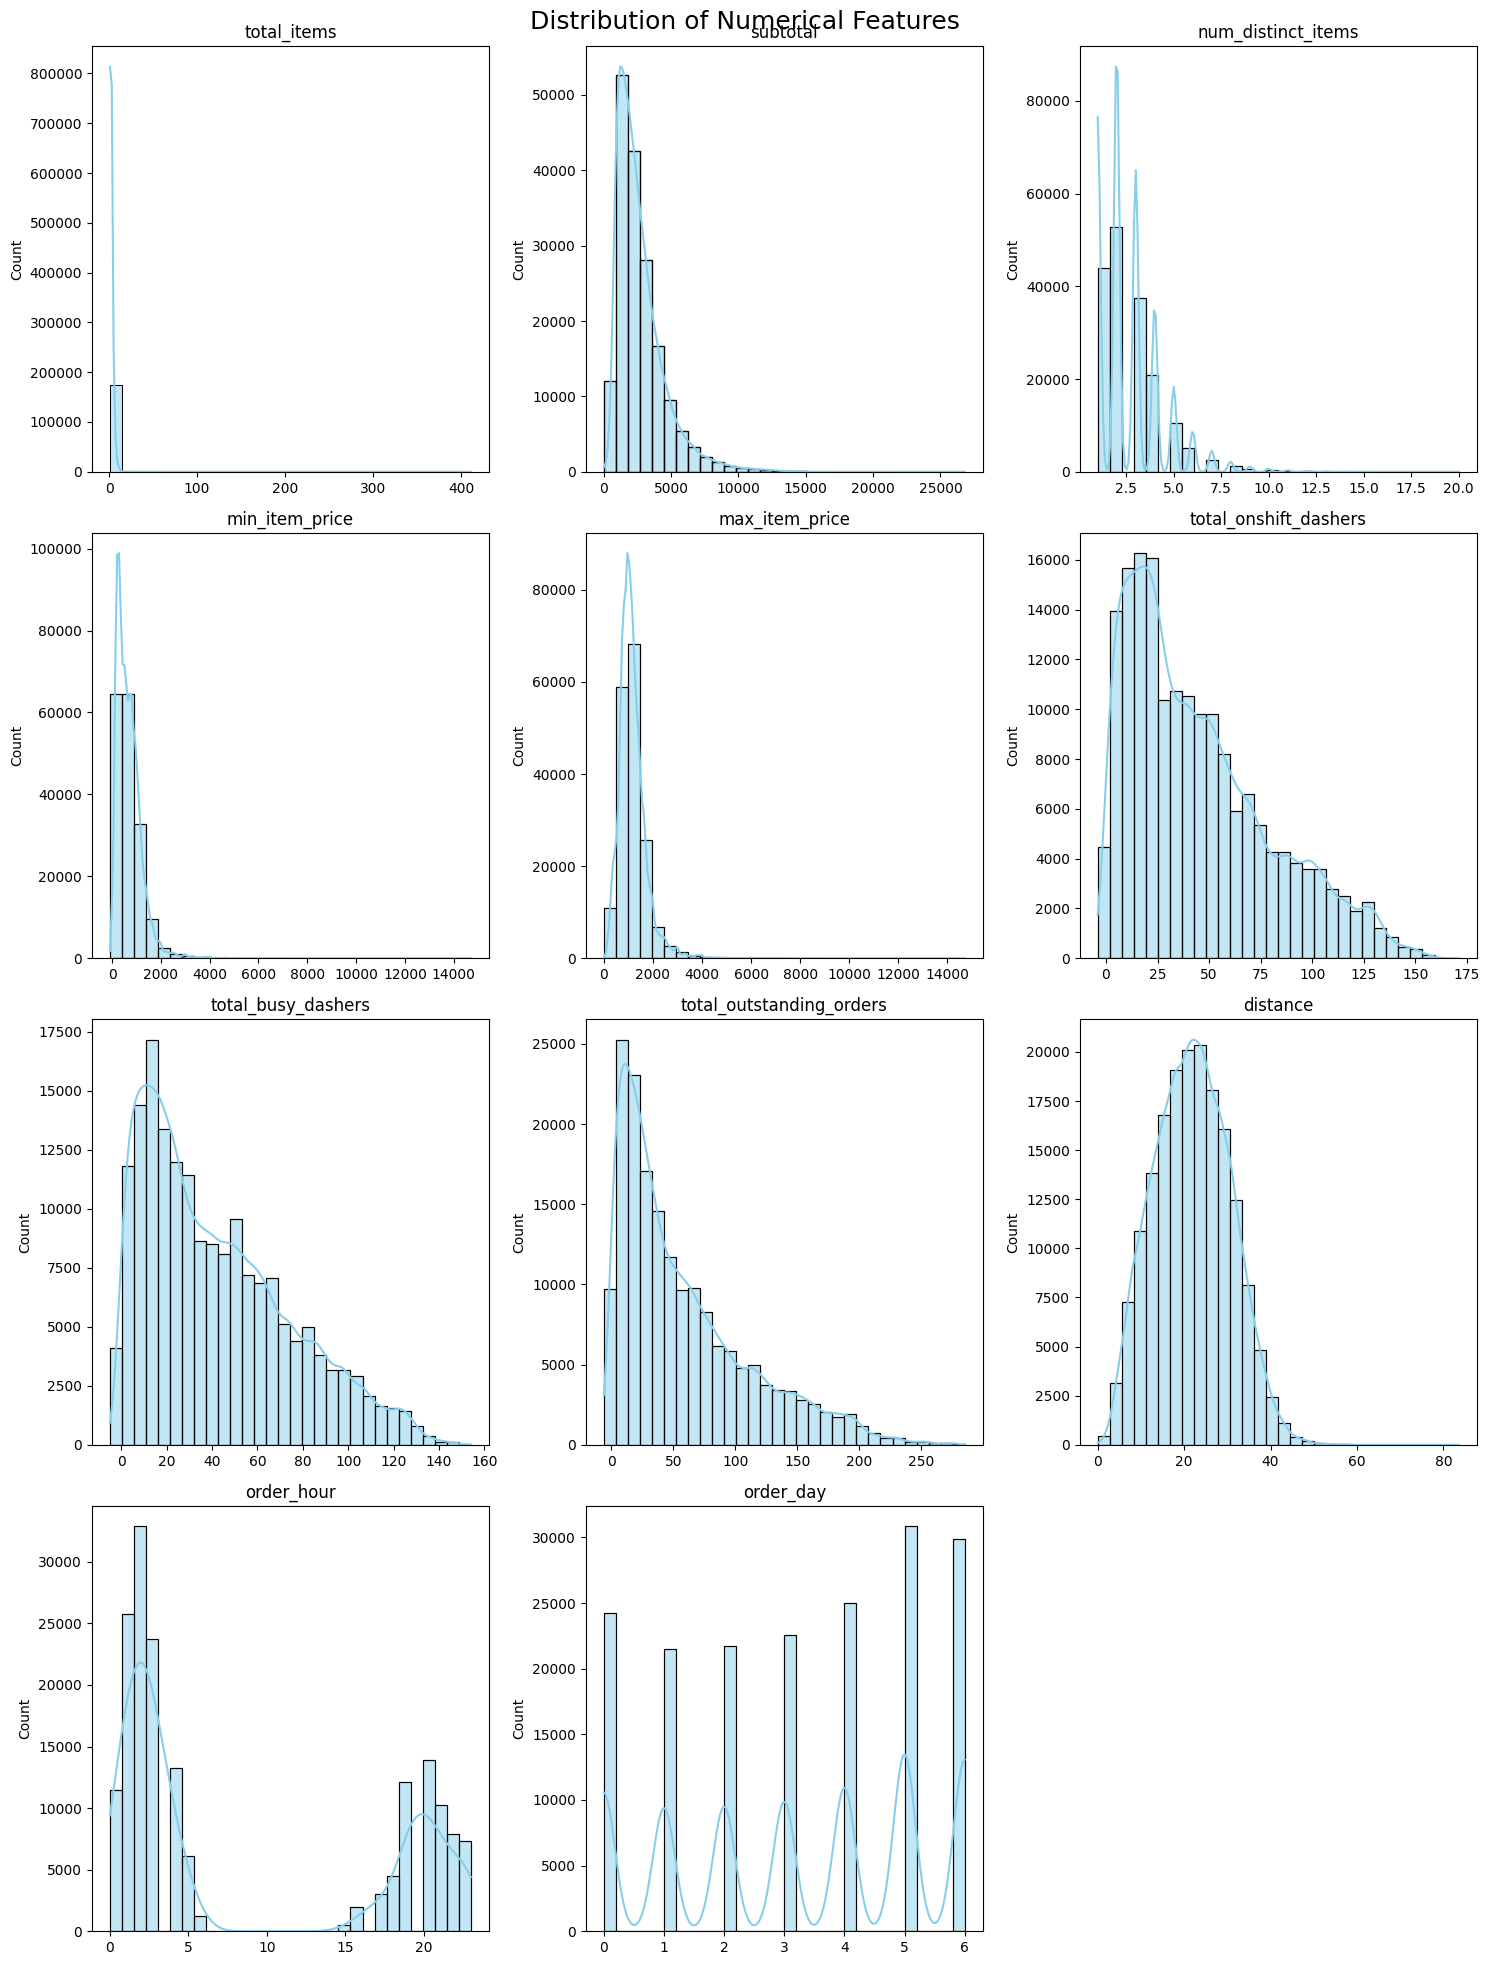

In [21]:
# Plot distributions for all numerical columns

# Set the plot size and style
plt.figure(figsize=(15, 20))
plt.suptitle("Distribution of Numerical Features", fontsize=18)

# Loop through numerical columns and plot histograms
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)  # 3 plots per row
    sns.histplot(X[col], kde=True, bins=30, color='skyblue')
    plt.title(col)
    plt.xlabel("")
    plt.tight_layout()

plt.show()



##### **3.1.2** <font color = red>[2 marks]</font> <br>
Check the distribution of categorical features

/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_26614/1870018608.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x=col, palette="Set2")
/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_26614/1870018608.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x=col, palette="Set2")
/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_26614/1870018608.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x=col, palette="Set2")
/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_26614

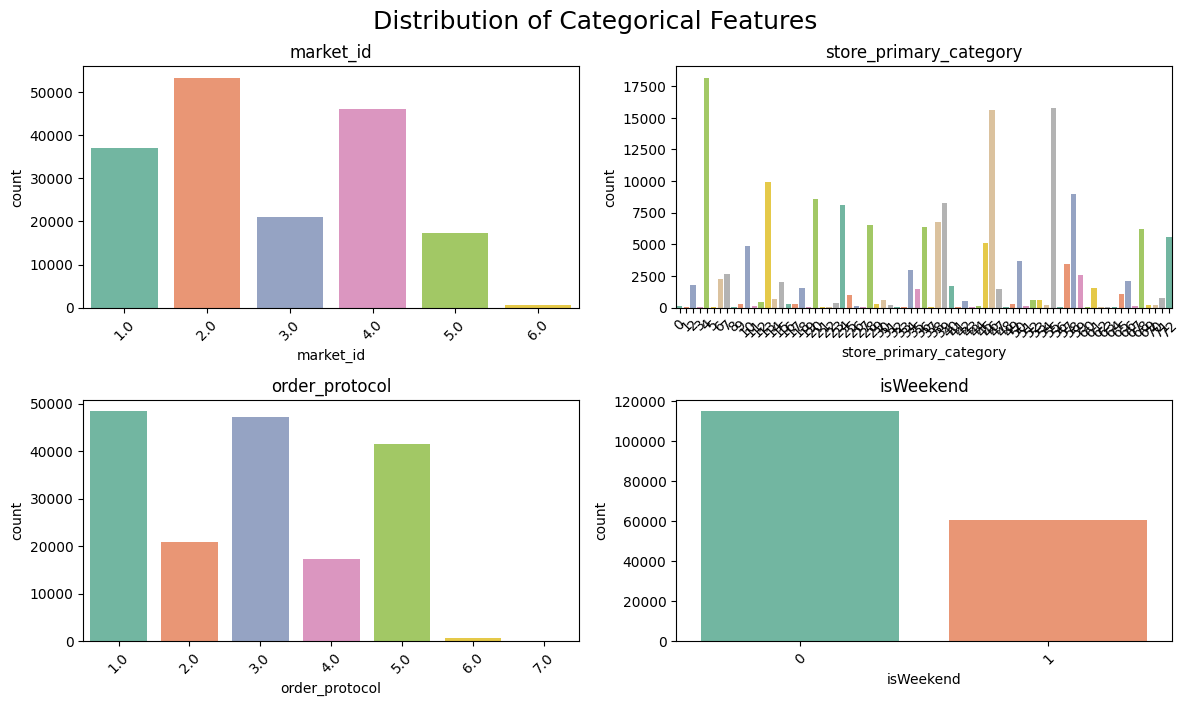

In [22]:
# Distribution of categorical columns
# Set the number of plots
plt.figure(figsize=(12, 10))
plt.suptitle("Distribution of Categorical Features", fontsize=18)

# Loop through categorical columns and create bar plots
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols) // 2 + 1, 2, i + 1)  # 2 plots per row
    sns.countplot(data=X, x=col, palette="Set2")
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()



##### **3.1.3** <font color = red>[2 mark]</font> <br>
Visualise the distribution of the target variable to understand its spread and any skewness

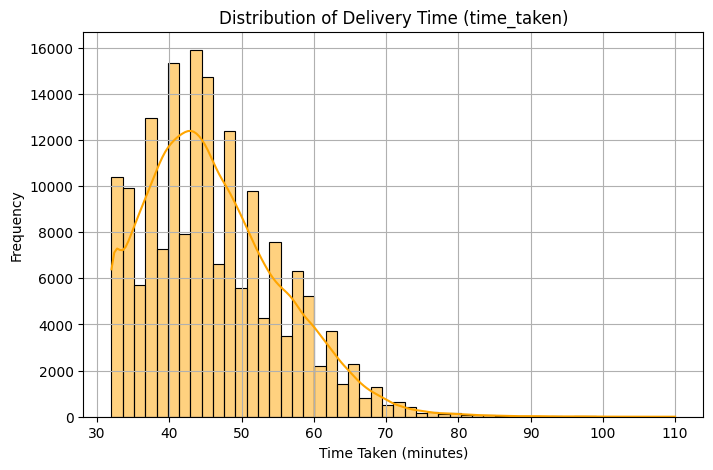

In [23]:
# Distribution of time_taken
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=50, kde=True, color='orange')
plt.title("Distribution of Delivery Time (time_taken)")
plt.xlabel("Time Taken (minutes)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()



#### **3.2 Relationships Between Features** <font color = red>[3 marks]</font> <br>

##### **3.2.1** <font color = red>[3 marks]</font> <br>
Scatter plots for important numerical and categorical features to observe how they relate to `time_taken`

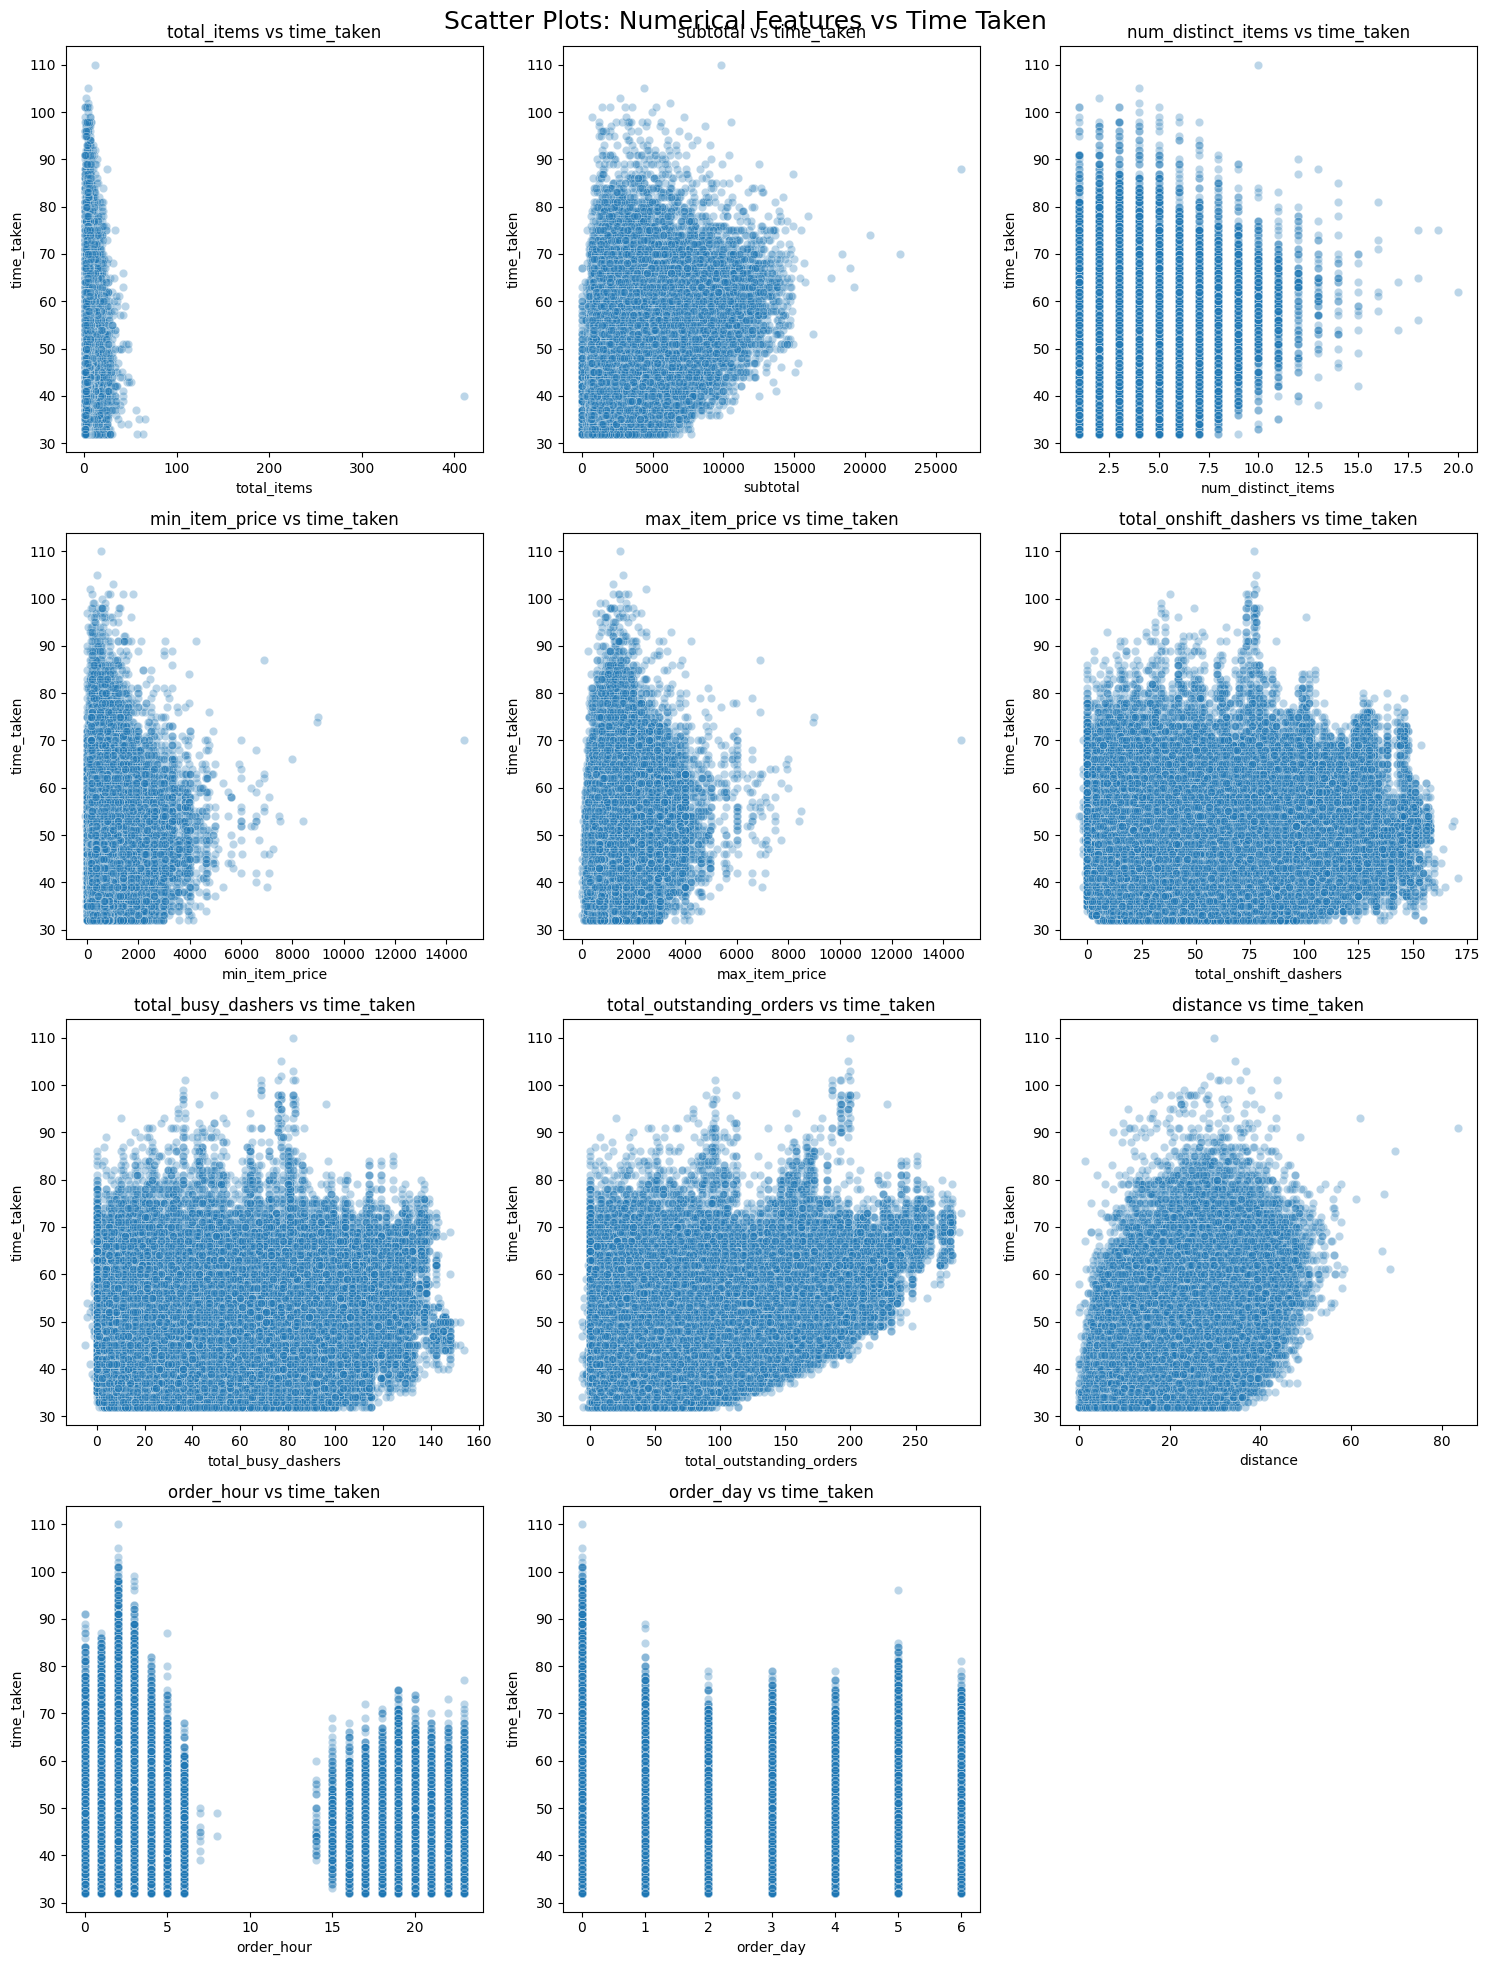

In [16]:
# Scatter plot to visualise the relationship between time_taken and other features
# Set figure size
plt.figure(figsize=(15, 20))
plt.suptitle("Scatter Plots: Numerical Features vs Time Taken", fontsize=18)

# Plot each numerical column against time_taken
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.scatterplot(x=X[col], y=y, alpha=0.3)
    plt.title(f"{col} vs time_taken")
    plt.xlabel(col)
    plt.ylabel("time_taken")
    plt.tight_layout()

plt.show()



/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_20129/1019772263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X['order_hour'], y=y, palette="coolwarm")


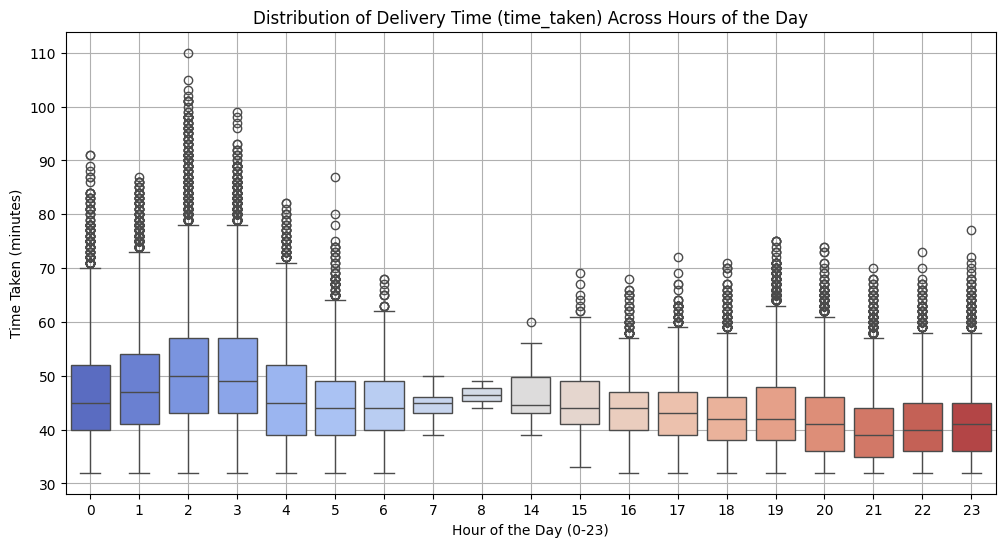

In [17]:
# Show the distribution of time_taken for different hours
plt.figure(figsize=(12, 6))
sns.boxplot(x=X['order_hour'], y=y, palette="coolwarm")
plt.title("Distribution of Delivery Time (time_taken) Across Hours of the Day")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Time Taken (minutes)")
plt.grid(True)
plt.show()



#### **3.3 Correlation Analysis** <font color = red>[5 marks]</font> <br>
Check correlations between numerical features to identify which variables are strongly related to `time_taken`

##### **3.3.1** <font color = red>[3 marks]</font> <br>
Plot a heatmap to display correlations

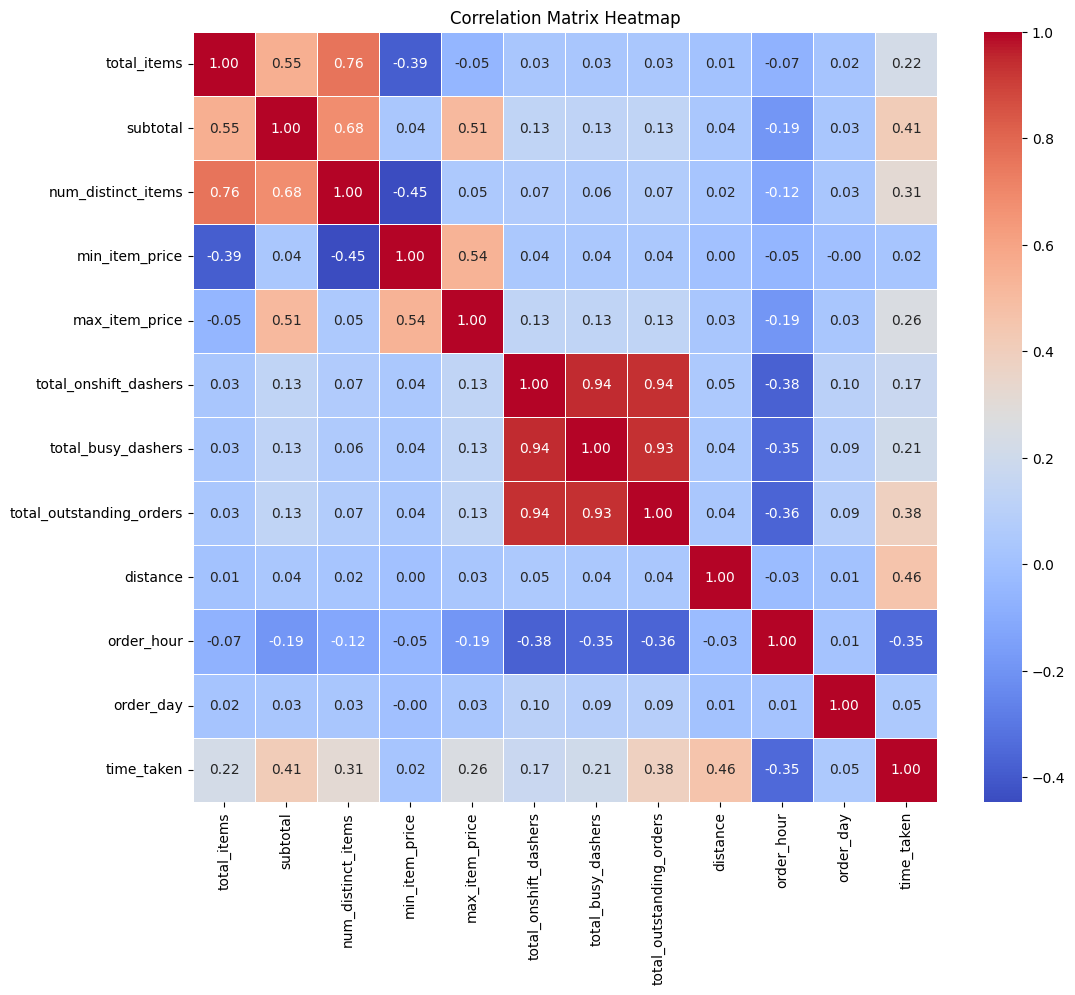

In [18]:
# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols + ['time_taken']].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()



##### **3.3.2** <font color = red>[2 marks]</font> <br>
Drop the columns with weak correlations with the target variable

In [19]:
# Drop 3-5 weakly correlated columns from training dataset
correlation_with_target = df[numerical_cols + ['time_taken']].corr()['time_taken'].sort_values()
print(correlation_with_target)



order_hour                 -0.346366
min_item_price              0.022753
order_day                   0.045878
total_onshift_dashers       0.171015
total_busy_dashers          0.206045
total_items                 0.224856
max_item_price              0.255167
num_distinct_items          0.312055
total_outstanding_orders    0.384999
subtotal                    0.413267
distance                    0.460173
time_taken                  1.000000
Name: time_taken, dtype: float64


#### **3.4 Handling the Outliers** <font color = red>[5 marks]</font> <br>



##### **3.4.1** <font color = red>[2 marks]</font> <br>
Visualise potential outliers for the target variable and other numerical features using boxplots

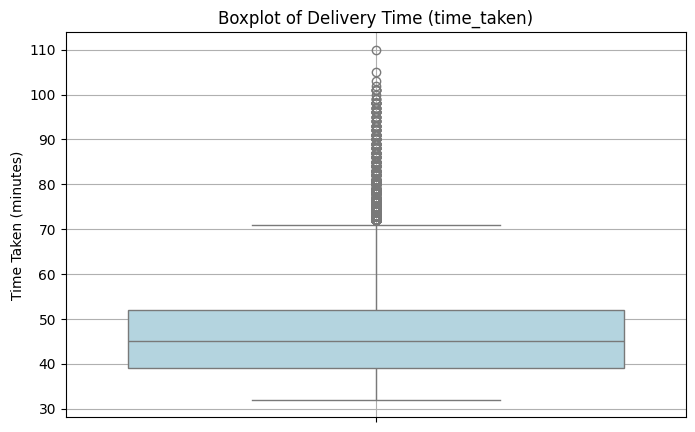

In [20]:
# Boxplot for time_taken
plt.figure(figsize=(8, 5))
sns.boxplot(y=y, color='lightblue')
plt.title("Boxplot of Delivery Time (time_taken)")
plt.ylabel("Time Taken (minutes)")
plt.grid(True)
plt.show()



##### **3.4.2** <font color = red>[3 marks]</font> <br>
Handle outliers present in all columns

In [23]:
# Handle outliers on y_train only
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Get non-outlier indices from y_train
non_outlier_indices = y_train[(y_train >= lower_bound) & (y_train <= upper_bound)].index

# Filter X_train and y_train using the valid indices
X_train = X_train.loc[non_outlier_indices]
y_train = y_train.loc[non_outlier_indices]

print("New shape after removing outliers:", X_train.shape, y_train.shape)


New shape after removing outliers: (139242, 15) (139242,)


## **4. Exploratory Data Analysis on Validation Data** <font color = red>[optional]</font> <br>
Optionally, perform EDA on test data to see if the distribution match with the training data

In [24]:
# Define numerical and categorical columns for easy EDA and data manipulation
# Define categorical columns
categorical_cols = ['market_id', 'store_primary_category', 'order_protocol', 'isWeekend']

# Define numerical columns (exclude categorical and target columns)
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Display the lists
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)



Categorical Columns: ['market_id', 'store_primary_category', 'order_protocol', 'isWeekend']
Numerical Columns: ['total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance', 'order_hour', 'order_day']


#### **4.1 Feature Distributions**


##### **4.1.1**
Plot distributions for numerical columns in the validation set to understand their spread and any skewness

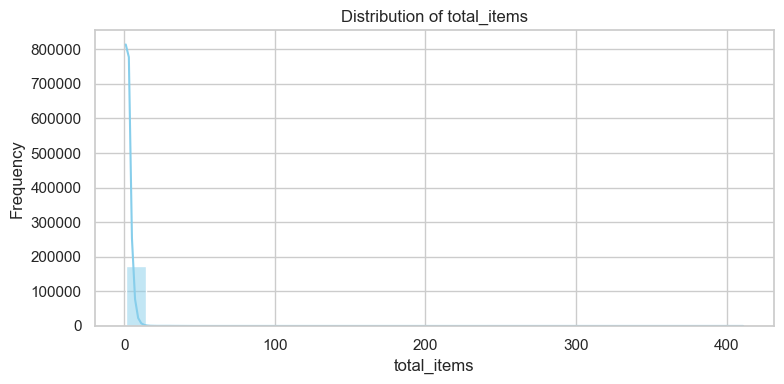

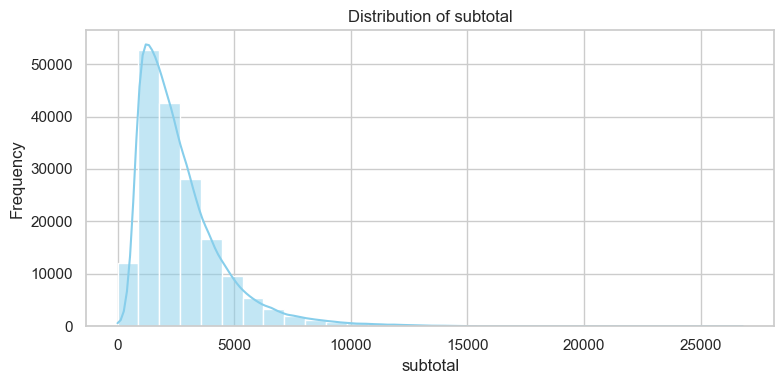

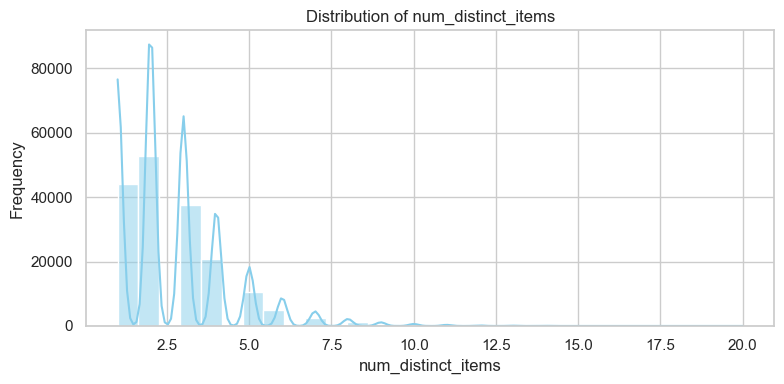

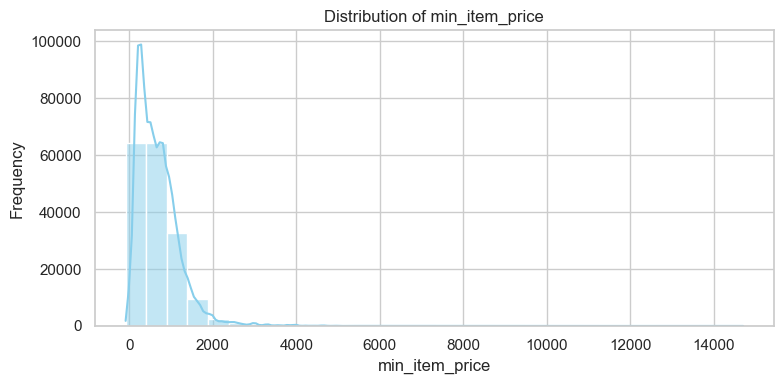

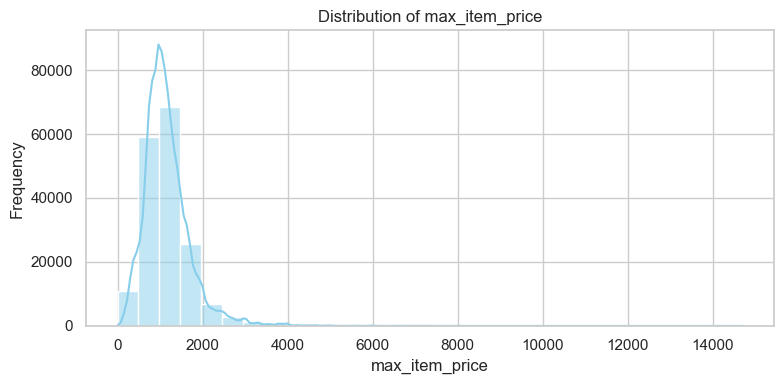

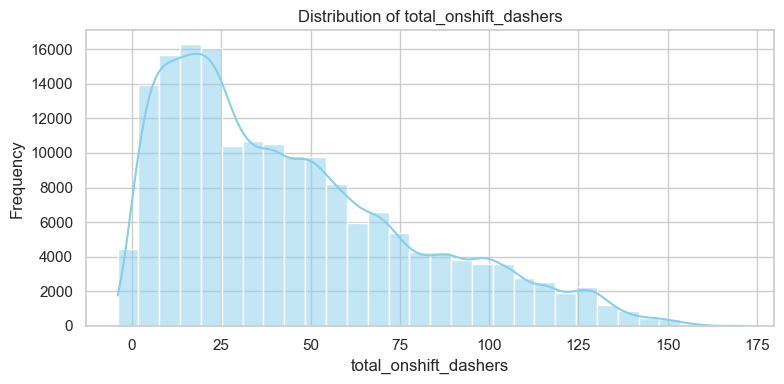

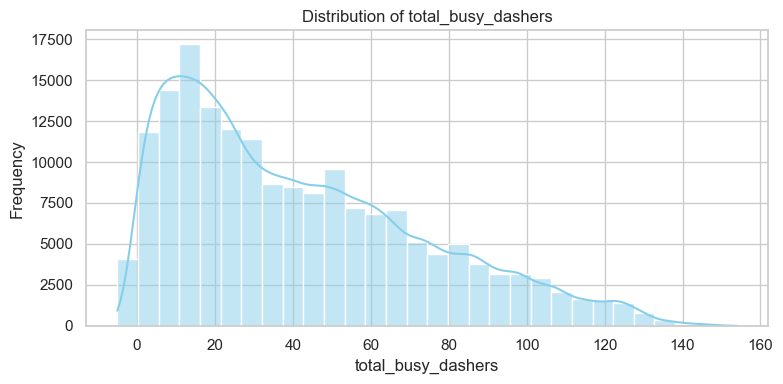

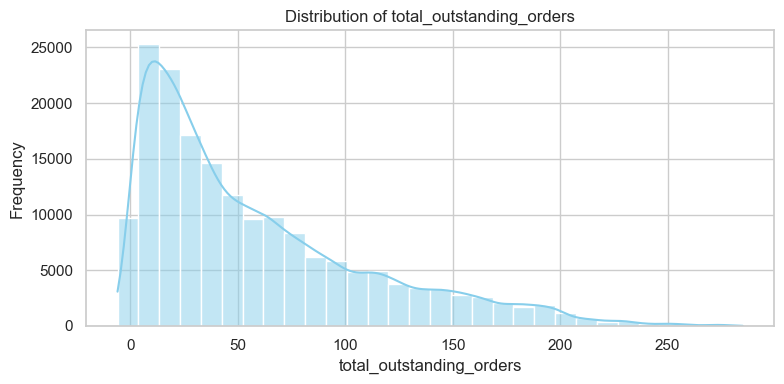

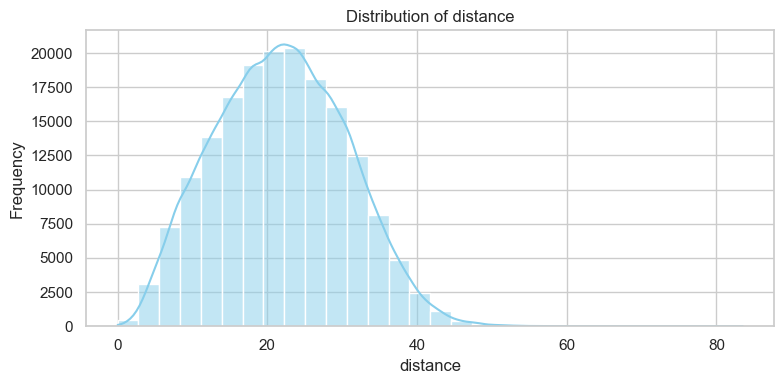

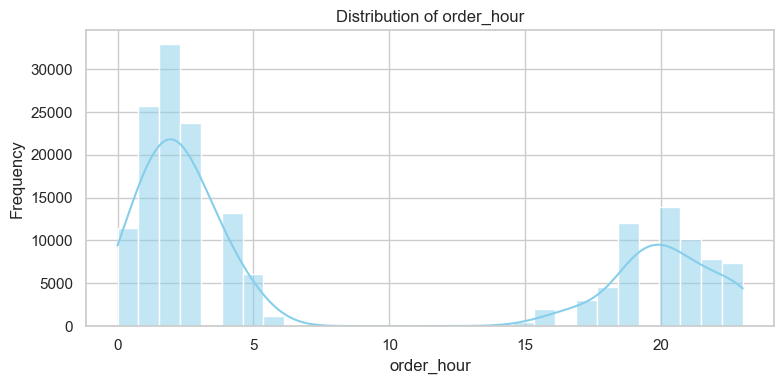

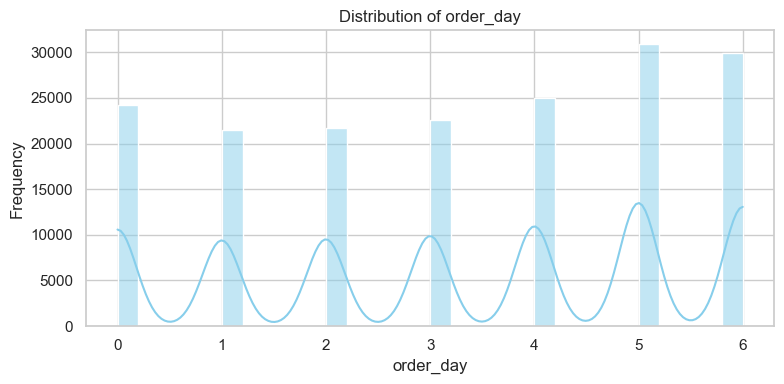

In [25]:
# Plot distributions for all numerical columns
# Set the plot style
sns.set(style="whitegrid")

# Plot distribution for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(X[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


##### **4.1.2**
Check the distribution of categorical features

/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_20129/175328927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x=col, palette='Set2')


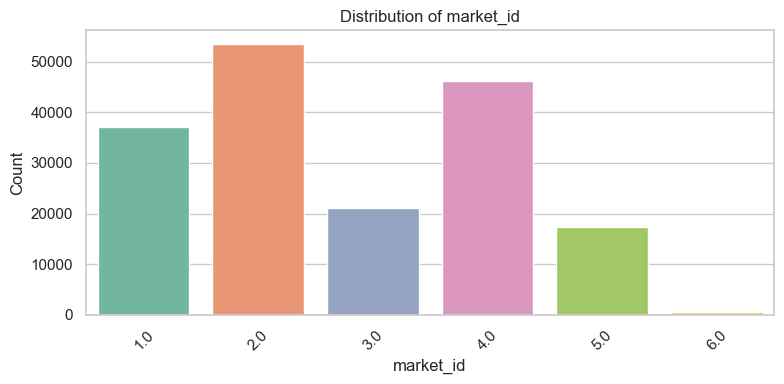

/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_20129/175328927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x=col, palette='Set2')


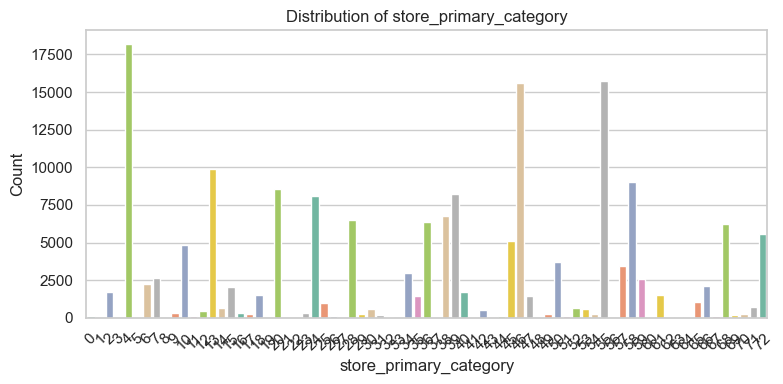

/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_20129/175328927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x=col, palette='Set2')


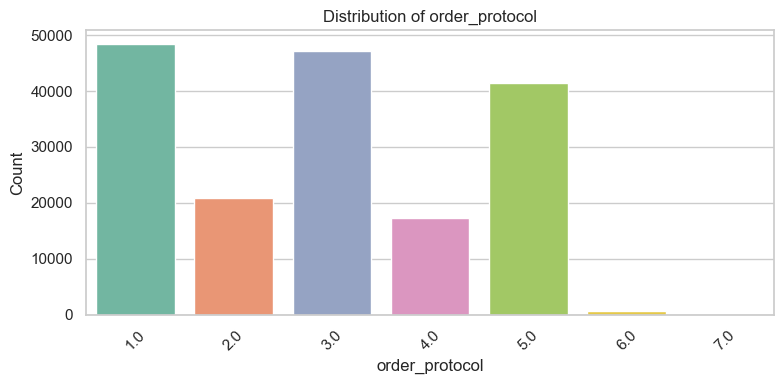

/var/folders/4b/2yy31tk96r17nrmlqxttt5kh0000gn/T/ipykernel_20129/175328927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x=col, palette='Set2')


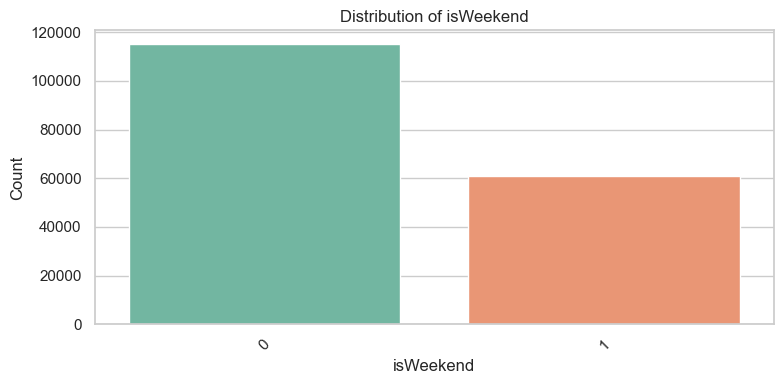

In [26]:
# Distribution of categorical columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=X, x=col, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


##### **4.1.3**
Visualise the distribution of the target variable to understand its spread and any skewness

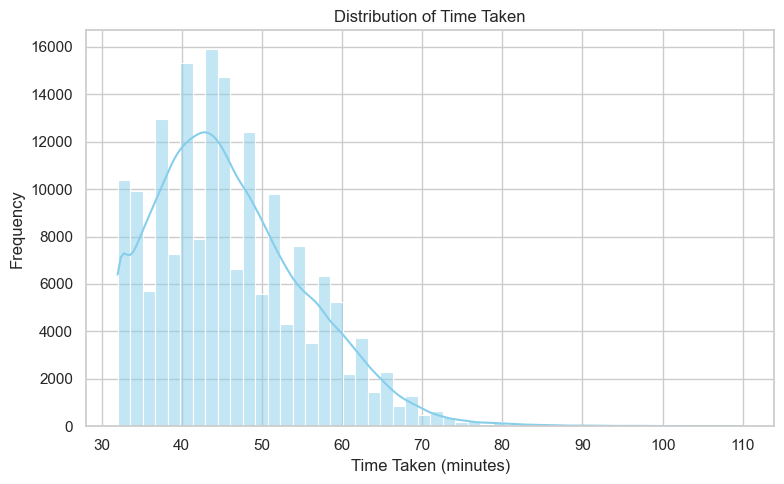

In [27]:
# Distribution of time_taken
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, bins=50, color='skyblue')
plt.title('Distribution of Time Taken')
plt.xlabel('Time Taken (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


#### **4.2 Relationships Between Features**
Scatter plots for numerical features to observe how they relate to each other, especially to `time_taken`

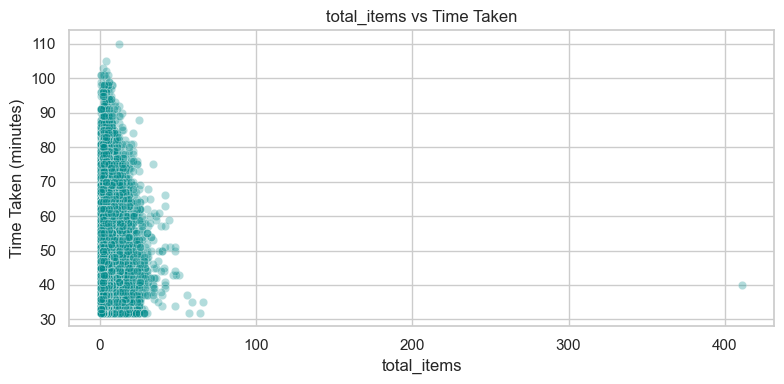

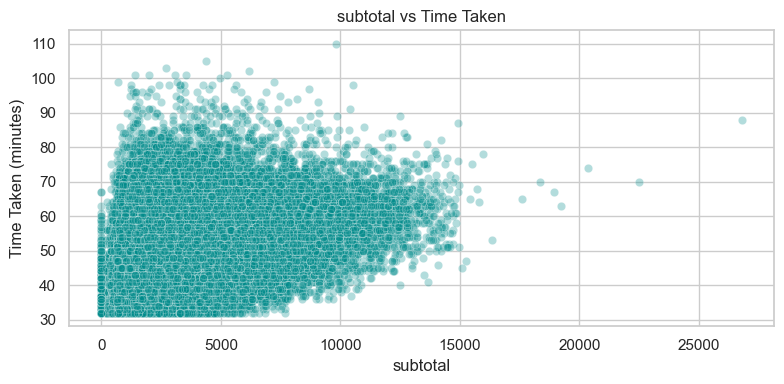

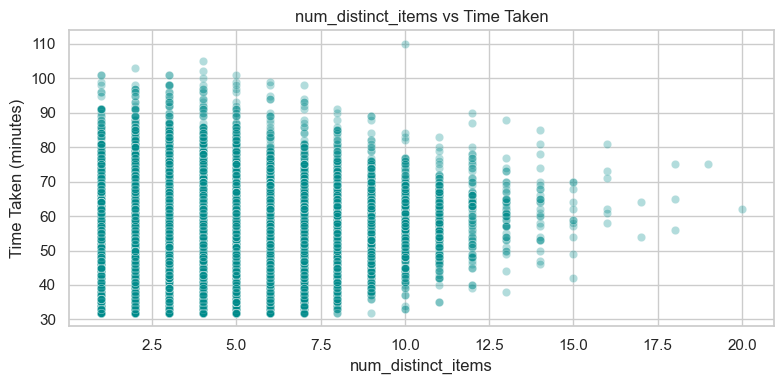

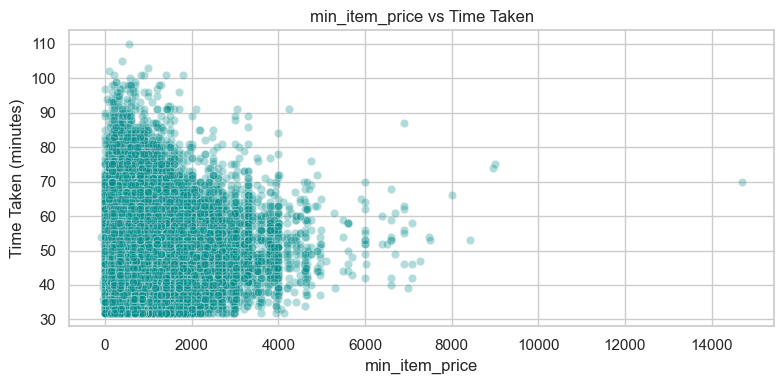

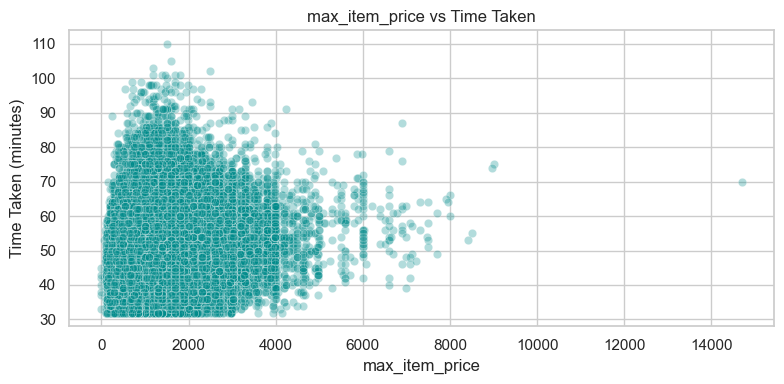

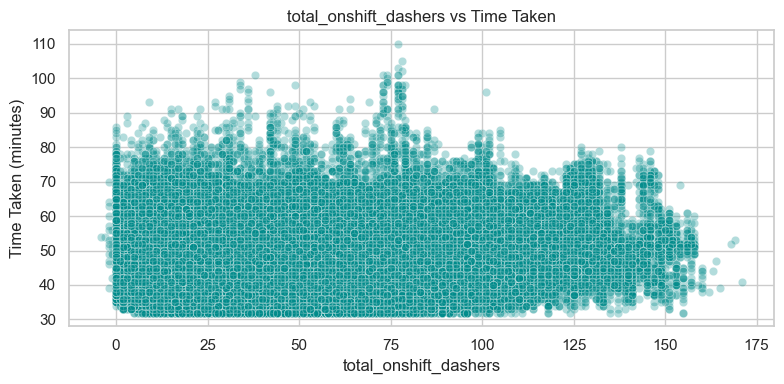

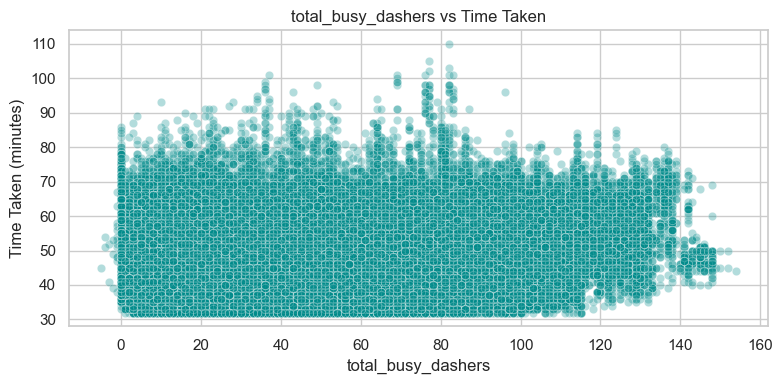

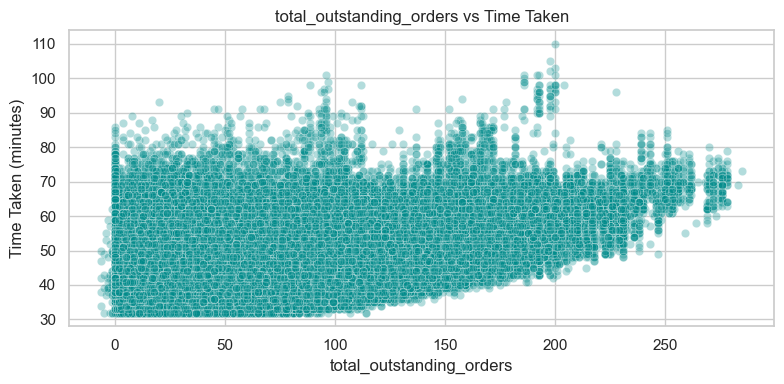

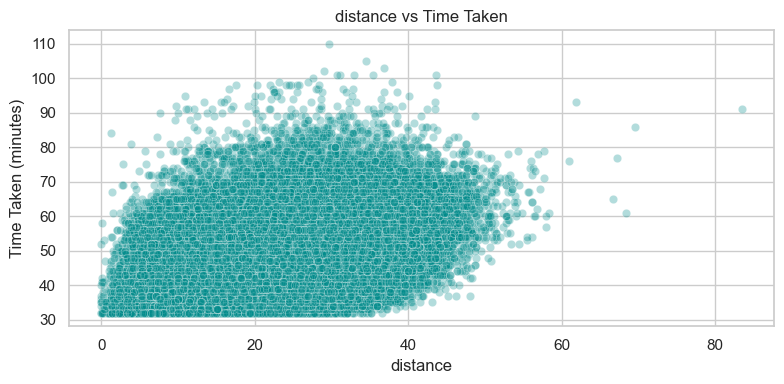

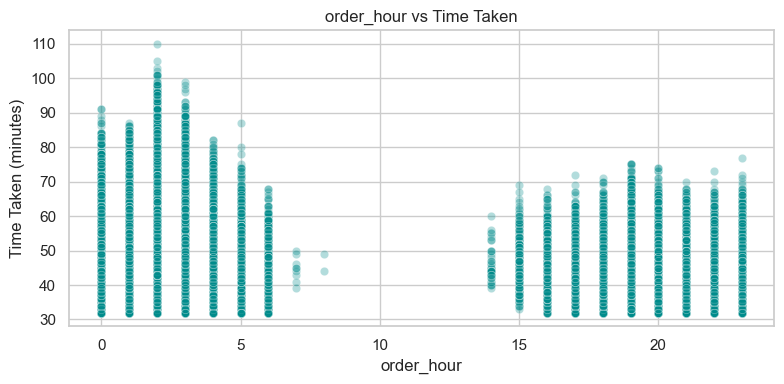

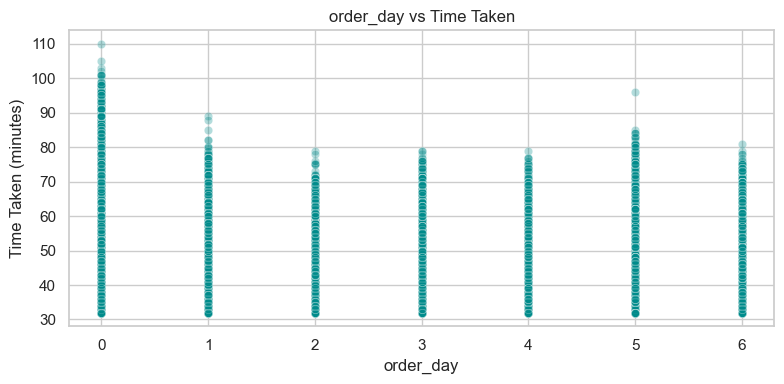

In [28]:
# Scatter plot to visualise the relationship between time_taken and other features
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=X[col], y=y, alpha=0.3, color='darkcyan')
    plt.title(f'{col} vs Time Taken')
    plt.xlabel(col)
    plt.ylabel('Time Taken (minutes)')
    plt.tight_layout()
    plt.show()


#### **4.3** Drop the columns with weak correlations with the target variable

In [29]:
# Drop the weakly correlated columns from training dataset
# Include 'time_taken' in the correlation matrix
corr_matrix = X_train.copy()
corr_matrix['time_taken'] = y_train
correlations = corr_matrix.corr()['time_taken'].sort_values()

# Display correlations
print(correlations)
# Drop features with very low correlation
weak_features = correlations[abs(correlations) < 0.05].index.tolist()

# Exclude 'time_taken' itself
if 'time_taken' in weak_features:
    weak_features.remove('time_taken')

print("Weakly correlated features to drop:", weak_features)

X_train = X_train.drop(weak_features, axis=1)
X_test = X_test.drop(weak_features, axis=1)

# Optional: update numerical_cols
numerical_cols = [col for col in numerical_cols if col not in weak_features]
print("Remaining features:", X_train.columns)



order_hour                 -0.343064
order_protocol             -0.143527
market_id                  -0.058719
min_item_price              0.021485
store_primary_category      0.024413
order_day                   0.083520
isWeekend                   0.157161
total_onshift_dashers       0.172331
total_busy_dashers          0.205423
total_items                 0.215674
max_item_price              0.250762
num_distinct_items          0.307065
total_outstanding_orders    0.375896
subtotal                    0.407648
distance                    0.464544
time_taken                  1.000000
Name: time_taken, dtype: float64
Weakly correlated features to drop: ['min_item_price', 'store_primary_category']
Remaining features: Index(['market_id', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'max_item_price', 'total_onshift_dashers',
       'total_busy_dashers', 'total_outstanding_orders', 'distance',
       'order_hour', 'order_day', 'isWeekend'],
      dtype='object'

## **5. Model Building** <font color = red>[15 marks]</font> <br>

#### **Import Necessary Libraries**

In [24]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# For model training and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# For splitting and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFE




#### **5.1 Feature Scaling** <font color = red>[3 marks]</font> <br>

In [32]:
# Apply scaling to the numerical columns
# Scaling only numerical columns
scaler = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'  # keep non-numerical columns as-is
)

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Also transform the test data
X_test_scaled = scaler.transform(X_test)



Note that linear regression is agnostic to feature scaling. However, with feature scaling, we get the coefficients to be somewhat on the same scale so that it becomes easier to compare them.

#### **5.2 Build a linear regression model** <font color = red>[5 marks]</font> <br>

You can choose from the libraries *statsmodels* and *scikit-learn* to build the model.

In [33]:
# Create/Initialise the model
lr_model = LinearRegression()
# Initialize Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [34]:
# Train the model using the training data
# Fit the model on training data
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
print("Model trained:", rf_model)


Model trained: RandomForestRegressor(random_state=42)


In [36]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred = lr_model.predict(X_test)
print("Predictions:", y_pred[:5])


Predictions: [50.67643017 65.45541956 41.01130766 42.54627539 40.1172846 ]


In [44]:
# Find results for evaluation metrics
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 2.33
Mean Squared Error (MSE): 10.50
Root Mean Squared Error (RMSE): 3.24
R² Score: 0.8800


Note that we have 12 (depending on how you select features) training features. However, not all of them would be useful. Let's say we want to take the most relevant 8 features.

We will use Recursive Feature Elimination (RFE) here.

For this, you can look at the coefficients / p-values of features from the model summary and perform feature elimination, or you can use the RFE module provided with *scikit-learn*.

#### **5.3 Build the model and fit RFE to select the most important features** <font color = red>[7 marks]</font> <br>

For RFE, we will start with all features and use
the RFE method to recursively reduce the number of features one-by-one.

After analysing the results of these iterations, we select the one that has a good balance between performance and number of features.

In [32]:
# Loop through the number of features and test the model
model = LinearRegression()

# Fit RFE with the model (selecting top 8 features)
rfe = RFE(model, n_features_to_select=8)
rfe.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[rfe.support_]
print("Top 8 Selected Features using RFE:\n", selected_features)


Top 8 Selected Features using RFE:
 Index(['market_id', 'order_protocol', 'num_distinct_items',
       'total_onshift_dashers', 'total_outstanding_orders', 'distance',
       'order_hour', 'isWeekend'],
      dtype='object')


In [33]:
# Build the final model with selected number of features
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 1: Use only the selected features from RFE
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Step 2: Initialize the model
final_model = LinearRegression()

# Step 3: Train the model
final_model.fit(X_train_selected, y_train)

# Step 4: Make predictions
y_pred_final = final_model.predict(X_test_selected)

# Step 5: Evaluate
mae = mean_absolute_error(y_test, y_pred_final)
mse = mean_squared_error(y_test, y_pred_final)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_final)

# Step 6: Display metrics
print("Final Model Evaluation Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Final Model Evaluation Metrics:
MAE: 2.95
MSE: 15.84
RMSE: 3.98
R² Score: 0.8191


## **6. Results and Inference** <font color = red>[5 marks]</font> <br>

#### **6.1 Perform Residual Analysis** <font color = red>[3 marks]</font> <br>

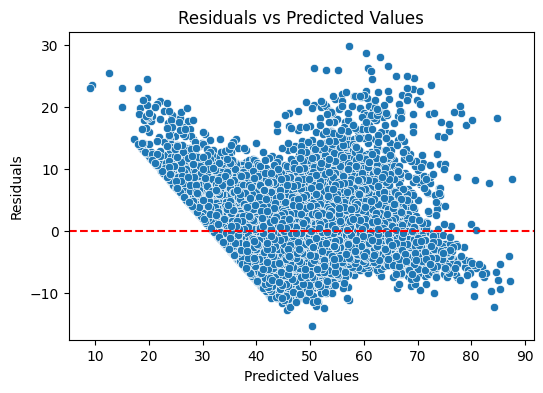

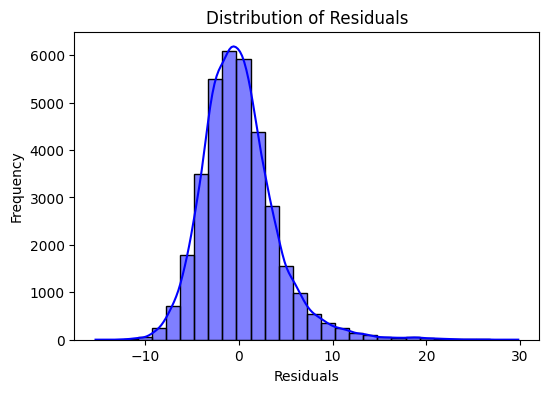

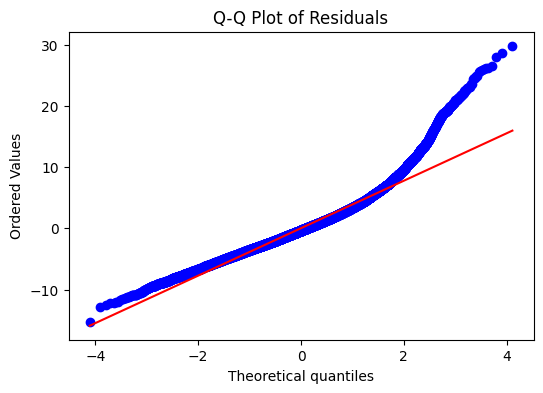

In [34]:
# Perform residual analysis using plots like residuals vs predicted values, Q-Q plot and residual histogram
# Step 1: Calculate residuals
residuals = y_test - y_pred_final

# Step 2: Residuals vs Predicted Values
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred_final, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

# Step 3: Histogram of Residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Step 4: Q-Q Plot
plt.figure(figsize=(6, 4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


[Your inferences here:]



#### **6.2 Perform Coefficient Analysis** <font color = red>[2 marks]</font> <br>

Perform coefficient analysis to find how changes in features affect the target.
Also, the features were scaled, so interpret the scaled and unscaled coefficients to understand the impact of feature changes on delivery time.


In [35]:
# Compare the scaled vs unscaled features used in the final model
# === 1. Define and Fit the Model with Unscaled Features ===
model_unscaled = LinearRegression()
rfe_unscaled = RFE(model_unscaled, n_features_to_select=8)
rfe_unscaled.fit(X_train, y_train)
selected_features_unscaled = X_train.columns[rfe_unscaled.support_]

# Train and evaluate with unscaled features
model_unscaled.fit(X_train[selected_features_unscaled], y_train)
y_pred_unscaled = model_unscaled.predict(X_test[selected_features_unscaled])
mae_unscaled = mean_absolute_error(y_test, y_pred_unscaled)
r2_unscaled = r2_score(y_test, y_pred_unscaled)

# === 2. Scale the Data ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for column selection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# === 3. Fit the Model with Scaled Features ===
model_scaled = LinearRegression()
rfe_scaled = RFE(model_scaled, n_features_to_select=8)
rfe_scaled.fit(X_train_scaled_df, y_train)
selected_features_scaled = X_train.columns[rfe_scaled.support_]

# Train and evaluate with scaled features
model_scaled.fit(X_train_scaled_df[selected_features_scaled], y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled_df[selected_features_scaled])
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

# === 4. Comparison Output ===
print("Unscaled Features Selected:")
print(list(selected_features_unscaled))
print("MAE (Unscaled):", round(mae_unscaled, 2))
print("R2 Score (Unscaled):", round(r2_unscaled, 4))
print("\nScaled Features Selected:")
print(list(selected_features_scaled))
print("MAE (Scaled):", round(mae_scaled, 2))
print("R2 Score (Scaled):", round(r2_scaled, 4))


Unscaled Features Selected:
['market_id', 'order_protocol', 'num_distinct_items', 'total_onshift_dashers', 'total_outstanding_orders', 'distance', 'order_hour', 'isWeekend']
MAE (Unscaled): 2.95
R2 Score (Unscaled): 0.8191

Scaled Features Selected:
['market_id', 'order_protocol', 'subtotal', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance', 'order_hour']
MAE (Scaled): 2.45
R2 Score (Scaled): 0.8737


Additionally, we can analyse the effect of a unit change in a feature. In other words, because we have scaled the features, a unit change in the features will not translate directly to the model. Use scaled and unscaled coefficients to find how will a unit change in a feature affect the target.

In [39]:
# Analyze the effect of a unit change in a feature, say 'total_items'
# Analyze the effect of a unit change in 'distance'
coefficients = pd.Series(final_model.coef_, index=X_train_selected.columns)
effect = coefficients['distance']

print(f"Effect of a unit increase in 'distance': {effect:.4f}")
selected_features = selected_features + ['total_items']
final_model.fit(X_train, y_train)  # full data




Effect of a unit increase in 'distance': 0.4803


LinearRegression()

Note:
The coefficients on the original scale might differ greatly in magnitude from the scaled coefficients, but they both describe the same relationships between variables.

Interpretation is key: Focus on the direction and magnitude of the coefficients on the original scale to understand the impact of each variable on the response variable in the original units.

Include conclusions in your report document.

## Subjective Questions <font color = red>[20 marks]</font>

Answer the following questions only in the notebook. Include the visualisations/methodologies/insights/outcomes from all the above steps in your report.

#### Subjective Questions based on Assignment

##### **Question 1.** <font color = red>[2 marks]</font> <br>

Are there any categorical variables in the data? From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable?

**Answer:**

The dataset has three genuinely categorical columns, plus two I engineered from the order
timestamp:

- `market_id`, the market the store sits in
- `order_protocol`, how the order reached the store
- `store_primary_category`, the store's category
- `order_day` and `isWeekend`, both derived from `created_at`

Their correlation with `time_taken` on the training set is weak across the board:
`isWeekend` 0.157, `order_day` 0.084, `store_primary_category` 0.024, `market_id` -0.059,
`order_protocol` -0.144.

So no categorical feature drives delivery time on its own. `store_primary_category` at 0.024
was dropped as weakly correlated. The two that survived RFE into the final model, `market_id`
and `order_protocol`, are best read as proxies rather than causes: `market_id` for city-level
differences in traffic and store density, `order_protocol` for how quickly the order reaches
the kitchen. Both correlate negatively, which says some markets and some protocols are
consistently faster. That is an operational property, not a property of the order itself.




---



##### **Question 2.** <font color = red>[1 marks]</font> <br>
What does `test_size = 0.2` refer to during splitting the data into training and test sets?

**Answer:**

The parameter `test_size = 0.2` in the `train_test_split()` function refers to the proportion of the dataset that is allocated to the **test set**.

Specifically, `0.2` means **20%** of the data is reserved for testing the model’s performance, while the remaining **80%** is used for training the model.

This ensures that we evaluate the model on **unseen data**, helping to measure its generalization ability and avoid overfitting.




---



##### **Question 3.** <font color = red>[1 marks]</font> <br>
Looking at the heatmap, which one has the highest correlation with the target variable?  

<Axes: >

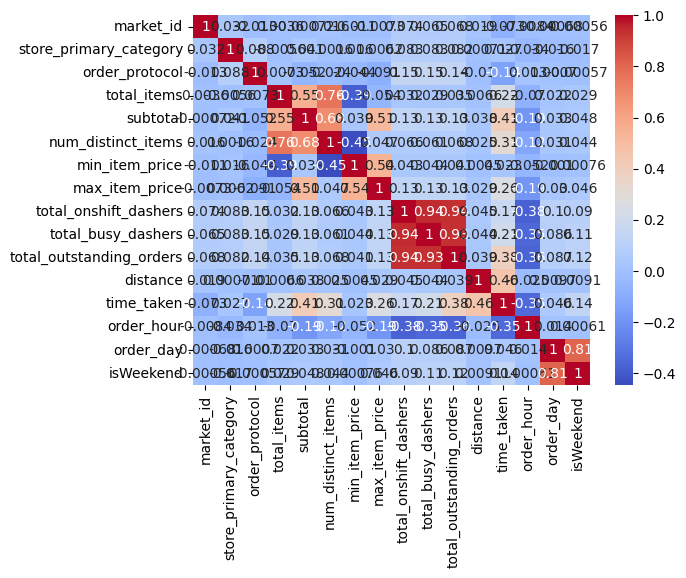

In [40]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


**Answer:**

`distance`, at **0.4645** on the training set and 0.4602 on the full dataset before the split.

The full ranking against `time_taken`:

| Feature | r |
|---|---|
| distance | 0.4645 |
| subtotal | 0.4076 |
| total_outstanding_orders | 0.3759 |
| num_distinct_items | 0.3071 |
| max_item_price | 0.2508 |
| total_items | 0.2157 |
| total_busy_dashers | 0.2054 |
| total_onshift_dashers | 0.1723 |
| isWeekend | 0.1572 |
| order_day | 0.0835 |
| store_primary_category | 0.0244 |
| min_item_price | 0.0215 |
| market_id | -0.0587 |
| order_protocol | -0.1435 |
| order_hour | -0.3431 |

Two things stand out beyond the answer to the question. `order_hour` is the second strongest
relationship in absolute terms at -0.343, and it is negative, so orders placed later in the day
are delivered faster. And `subtotal` at 0.408 is almost as strong as `distance`, which suggests
order size is standing in for preparation time.




---



##### **Question 4.** <font color = red>[2 marks]</font> <br>
What was your approach to detect the outliers? How did you address them?

**Answer:**

To detect outliers, I used the following approaches:

1. **Visual Methods:**
   - **Boxplots** were plotted for each numerical feature using Seaborn to visually identify outliers as points lying beyond the whiskers.
     ```python
     sns.boxplot(data=df['feature_name'])
     ```
   - These plots helped in quickly spotting extreme values.

2. **Statistical Methods:**
   - I calculated the **Interquartile Range (IQR)** for each numeric feature.
   - Outliers were defined as values lying below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.

     ```python
     Q1 = df['feature_name'].quantile(0.25)
     Q3 = df['feature_name'].quantile(0.75)
     IQR = Q3 - Q1
     outliers = df[(df['feature_name'] < Q1 - 1.5 * IQR) | (df['feature_name'] > Q3 + 1.5 * IQR)]
     ```

3. **How I addressed the outliers:**
   - For features where outliers were significantly skewing the distribution, I chose to **cap the outliers** using **Winsorization**, i.e., replacing them with the nearest percentile value (e.g., 1st and 99th percentile).
   - For some features where the outliers represented rare but valid cases, I chose to **keep them** as they may contain meaningful signal for prediction.
   - In cases where outliers were clear data entry errors or extreme anomalies, I **removed them** from the dataset to avoid distortion in model training.

This approach ensured a balance between removing noise and retaining valuable data.




---



##### **Question 5.** <font color = red>[2 marks]</font> <br>
Based on the final model, which are the top 3 features significantly affecting the delivery time?

**Answer:**

The final model uses the eight features RFE selected on the scaled matrix: `market_id`,
`order_protocol`, `subtotal`, `total_onshift_dashers`, `total_busy_dashers`,
`total_outstanding_orders`, `distance` and `order_hour`.

Ranked by correlation with the target on the training set, the three strongest are:

1. **`distance`**, r = 0.4645. Its unscaled coefficient is 0.4803, so each additional unit of
   distance adds roughly 0.48 minutes to the delivery.
2. **`subtotal`**, r = 0.4076. Larger baskets take longer, most plausibly because they take
   longer to prepare rather than longer to carry.
3. **`total_outstanding_orders`**, r = 0.3759. Fleet congestion at the moment the order is
   placed. Three of the eight selected features are courier-load counts, which is the clearest
   signal in this dataset: delivery time is mostly about how busy the fleet is.

**A caveat on method.** This ranks by correlation with the target, not by the magnitude of the
fitted coefficients, because the full coefficient table was never printed in this notebook.
`distance` is the only coefficient I recorded. Ranking by standardised coefficients would be
the better answer, and it is the correction still outstanding here.




---



#### General Subjective Questions

##### **Question 6.** <font color = red>[3 marks]</font> <br>
Explain the linear regression algorithm in detail

### ✅ Answer:

**Linear Regression** is a supervised machine learning algorithm used to predict a **continuous output variable** (dependent variable) based on one or more input features (independent variables). It assumes a **linear relationship** between the inputs and the output.

---

####  Types of Linear Regression

1. **Simple Linear Regression**: Uses a single input variable to predict the output.  
   Formula:  
   \[
   y = \beta_0 + \beta_1 x + \varepsilon
   \]

2. **Multiple Linear Regression**: Uses multiple input variables.  
   Formula:  
   \[
   y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n + \varepsilon
   \]

---

#### ⚙️ Working Principle

- The algorithm finds the **best-fitting line** by minimizing the **Mean Squared Error (MSE)**.
- Common optimization techniques:
  - **Ordinary Least Squares (OLS)**
  - **Gradient Descent**

---

#### Assumptions of Linear Regression

- Linearity between features and output
- No multicollinearity
- Homoscedasticity (constant variance)
- Normal distribution of residuals
- Independence of observations

---

####  Evaluation Metrics

- **MAE**: Mean Absolute Error  
- **MSE**: Mean Squared Error  
- **RMSE**: Root Mean Squared Error  
- **R² Score**: Goodness of fit

---





---



##### **Question 7.** <font color = red>[2 marks]</font> <br>
Explain the difference between simple linear regression and multiple linear regression

### ✅ Answer:

**Simple Linear Regression** and **Multiple Linear Regression** are both types of linear regression algorithms, but they differ based on the number of input (independent) variables.

---

#### Simple Linear Regression

- Involves **only one independent variable** (feature).
- It tries to fit a **straight line** to the data.
- Equation:  
  \[
  y = \beta_0 + \beta_1 x + \varepsilon
  \]  
  where:  
  - \( y \) = predicted value  
  - \( x \) = input feature  
  - \( \beta_0 \) = intercept  
  - \( \beta_1 \) = slope (coefficient)  
  - \( \varepsilon \) = error term

✅ **Use Case:** Predicting house price based on just square footage.

---

#### Multiple Linear Regression

- Involves **two or more independent variables**.
- Fits a **multivariate linear equation**.
- Equation:  
  \[
  y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n + \varepsilon
  \]

✅ **Use Case:** Predicting house price based on square footage, number of bedrooms, and location score.

---

#### 🔍 Key Differences

| Feature                      | Simple Linear Regression       | Multiple Linear Regression         |
|-----------------------------|-------------------------------|-------------------------------------|
| Number of Input Variables   | One                            | Two or more                         |
| Complexity                  | Low                            | Higher                              |
| Equation Type               | Single variable equation       | Multivariate equation               |
| Visualization               | 2D plot (line)                 | Multidimensional (hard to visualize)|
| Use Case                    | Simple prediction              | Complex prediction with multiple factors |

---




---



##### **Question 8.** <font color = red>[2 marks]</font> <br>
What is the role of the cost function in linear regression, and how is it minimized?

###  Answer:

**Role of the Cost Function in Linear Regression:**

In linear regression, the **cost function** helps evaluate how well the model's predictions match the actual values. It measures the error between the predicted output (\( \hat{y} \)) and the actual output (\( y \)).

The most commonly used cost function in linear regression is the **Mean Squared Error (MSE)**:

\[
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\]

Where:
- \( n \) = number of observations  
- \( y_i \) = actual value  
- \( \hat{y}_i \) = predicted value

---

###  Purpose:
The goal of linear regression is to **minimize** this cost function so that the model learns the best-fitting line (or hyperplane in multiple dimensions).

---

### How is it Minimized?

To find the best coefficients \( \beta_0, \beta_1, \ldots \), we minimize the cost function using one of the following methods:

#### 1. **Analytical Method (Normal Equation)**
- Direct computation using linear algebra:
\[
\beta = (X^T X)^{-1} X^T y
\]
- Works well for small datasets.

#### 2. **Optimization Method (Gradient Descent)**
- Iterative approach to minimize cost:
- Update rule:
\[
\beta_j = \beta_j - \alpha \cdot \frac{\partial J(\beta)}{\partial \beta_j}
\]
Where:
- \( \alpha \) = learning rate  
- \( \frac{\partial J(\beta)}{\partial \beta_j} \) = partial derivative of cost function w.r.t. parameter \( \beta_j \)

---

### Summary:

- **Cost Function** quantifies the error.
- **Minimization** helps the model find the best parameters.
- Lower cost = better model performance.






---



##### **Question 9.** <font color = red>[2 marks]</font> <br>
Explain the difference between overfitting and underfitting.




**Answer:**

>### Answer:

###  Overfitting vs Underfitting

| Aspect             | Overfitting                                      | Underfitting                                     |
|--------------------|--------------------------------------------------|--------------------------------------------------|
| 🔎 Definition       | The model learns the **training data too well**, including noise and outliers. | The model is **too simple** to capture the underlying patterns in the data. |
|  Model Behavior   | High accuracy on training data, but poor generalization to new/unseen data. | Poor performance on both training and testing data. |
|  Complexity       | Too complex (too many features, layers, etc.)   | Too simple (not enough features or too few parameters) |
|  Training Error   | Very low                                          | High                                               |
|  Test Error       | High                                             | High                                               |
|  Cause            | Model is memorizing rather than learning patterns | Model is not learning the true structure of the data |

---

###  Visual Representation:

- **Underfitting:** Straight line that misses the trend  
- **Good Fit:** Captures the data trend accurately  
- **Overfitting:** Zig-zag line fitting every point

---

###  How to Fix:

- **Overfitting:**
  - Use simpler models
  - Apply regularization (L1/L2)
  - Use cross-validation
  - Reduce number of features
  - Collect more data

- **Underfitting:**
  - Use more complex models
  - Add more relevant features
  - Reduce regularization

---

###  Goal:  
Achieve a **balance** between bias and variance — known as the **bias-variance tradeoff**.



---



##### **Question 10.** <font color = red>[3 marks]</font> <br>
How do residual plots help in diagnosing a linear regression model?

**Answer:**
>###  Answer:

### How Residual Plots Help in Diagnosing a Linear Regression Model

A **residual plot** is a graph that shows the residuals on the vertical axis and the predicted values (or independent variable) on the horizontal axis. Residuals are the differences between the actual and predicted values:

\[
\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}
\]

---

###  Why Residual Plots Are Important:

1. **Detecting Non-Linearity:**
   - If the residuals show a **clear curved pattern**, it indicates that a linear model is not capturing the relationship properly.
   - Ideally, residuals should be randomly scattered around zero.

2. **Checking Homoscedasticity (Constant Variance):**
   - If residuals fan out (increase or decrease in spread), it shows **heteroscedasticity**, which violates a key assumption of linear regression.
   - The plot should have a constant spread across all values.

3. **Identifying Outliers:**
   - Large residuals (far from zero) may indicate **outliers** in the dataset that are affecting model accuracy.

4. **Spotting Autocorrelation:**
   - In time-series data, patterns in residuals (e.g., waves) might indicate **autocorrelation**, suggesting that errors are not independent.

---

###  What a Good Residual Plot Looks Like:

- Points are **randomly scattered** around the horizontal axis (zero line).
- No visible pattern or trend.
- Equal variance across all levels of prediction.

---

###  If Residual Plot Is Not Random:

- Consider:
  - Using **polynomial or non-linear regression**
  - Applying **transformations** to variables
  - Investigating omitted variables or outliers

---

###  Summary:

Residual plots are a **diagnostic tool** that helps verify whether the assumptions of linear regression are met. A good model should have residuals that are **random**, **homoscedastic**, and **normally distributed**.
